## Sources 
   
1. [Article](https://www.nature.com/articles/s41598-026-39392-9)
2. [Quantum Machine Learning - Claudio Conti](https://link.springer.com/book/10.1007/978-3-031-44226-1)
3. [Quantum Kernels](https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/quantum-kernel-methods)


### DataSet
[Blood Transfusion Service Center](https://archive.ics.uci.edu/dataset/176/blood+transfusion+service+center) from UC Irvine Machine Learning Repository

In [39]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

from qiskit import QuantumCircuit



In [40]:
import src.plot_utils as plots 
import src.utils as utils


In [ ]:
df = pd.read_csv('dataset/transfusion.data',dtype=np.float64)
df[df.columns[:-1]].corr()


,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months)
Recency (months),1.000000,-0.182745,-0.182745,0.160618
Frequency (times),-0.182745,1.000000,1.000000,0.634940
Monetary (c.c. blood),-0.182745,1.000000,1.000000,0.634940
Time (months),0.160618,0.634940,0.634940,1.000000


- we will choose the features which are highly non co-related \
    i.e  Recency (months) and Time (months)

In [ ]:
X,y = df[['Recency (months)', 'Time (months)']].values,df[df.columns[-1]].values


- we will take 75% for ta
- And normalize our training data to 0 to pi 




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
# ---- normalize to [0, π] ----
scaler = MinMaxScaler(feature_range=(0, np.pi))

norm_X_train = scaler.fit_transform(X_train)
norm_X_test  = scaler.transform(X_test)

X_small, _, y_small, _ = train_test_split(
    norm_X_train,
    y_train,
    train_size=100,
    stratify=y_train,
    random_state=42
)


### Our 4 parameterized phi circuits where we can change theta 
1.  $x*y$
2.  $e^{{((x-y)/\pi)}}$
3.  $(x^{2}+y^{2})/\pi$
4.  $ \pi(1-x)(1-y)$

In [ ]:
def phi1(x, y):
    return x*y
def phi2(x, y):
    return np.exp((x-y)/np.pi)
def phi3(x, y):
    return (x**2+y**2)/np.pi
def phi4(x, y):
    return np.pi*(1-x)*(1-y)

phis = [phi1,phi2,phi3,phi4]
sign_phis = [
    '$xy$',
    '$e^{{((x-y)/\pi)}}$', 
    '$(x^{2}+y^{2})/\pi$',
    '$ \pi(1-x)(1-y)$'
]
plots.folder()


'result'

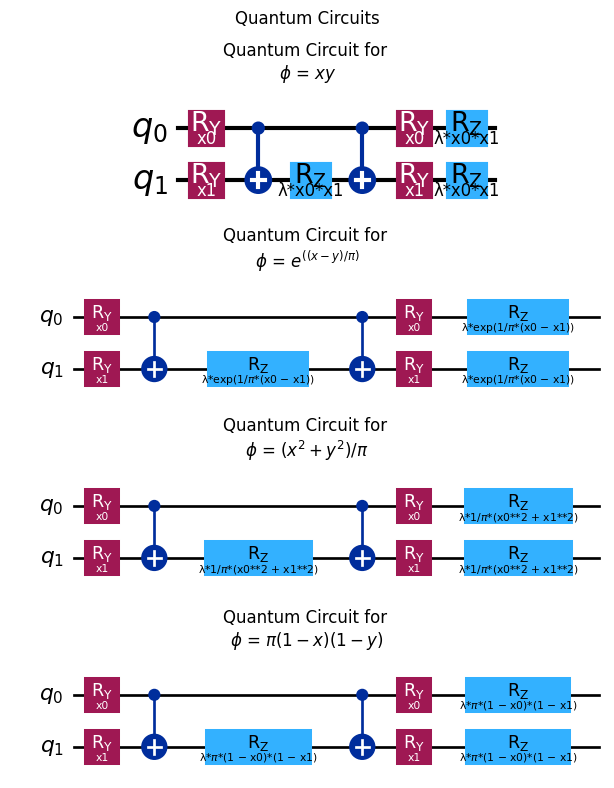

In [45]:
fig,axs = plt.subplots(4,1)
fig.set_size_inches(10,8)
axs = axs.flatten()

for phi,phisi,ax in zip(phis,sign_phis,axs):
    
    feature_qc = QuantumCircuit(2)
    _, feature_qc = utils.featureMap(feature_qc, phi)
    feature_qc.draw('mpl',ax=ax)
    ax.set_title('Quantum Circuit for \n'+  rf'$\phi$ = {phisi}')

fig.suptitle('Quantum Circuits')
fig.tight_layout()
plt.show()
fig.savefig('result/quantum_circuits.jpg')


In [ ]:
feature_qc = QuantumCircuit(2)
# _, feature_qc = utils.featureMap(feature_qc, phi1)
feature_qc.depth()


0

test λ=0.5: 100%|██████████| 187/187 [00:28<00:00,  6.64it/s]


λ = 0.5, accuracy = 0.765
n_support: 54
dual_coef shape: (1, 54)


test λ=0.5: 100%|██████████| 187/187 [00:27<00:00,  6.74it/s]


λ = 0.5, accuracy = 0.765
n_support: 55
dual_coef shape: (1, 55)


test λ=0.5: 100%|██████████| 187/187 [00:28<00:00,  6.66it/s]


λ = 0.5, accuracy = 0.765
n_support: 56
dual_coef shape: (1, 56)


test λ=0.5: 100%|██████████| 187/187 [00:28<00:00,  6.66it/s]


λ = 0.5, accuracy = 0.765
n_support: 53
dual_coef shape: (1, 53)


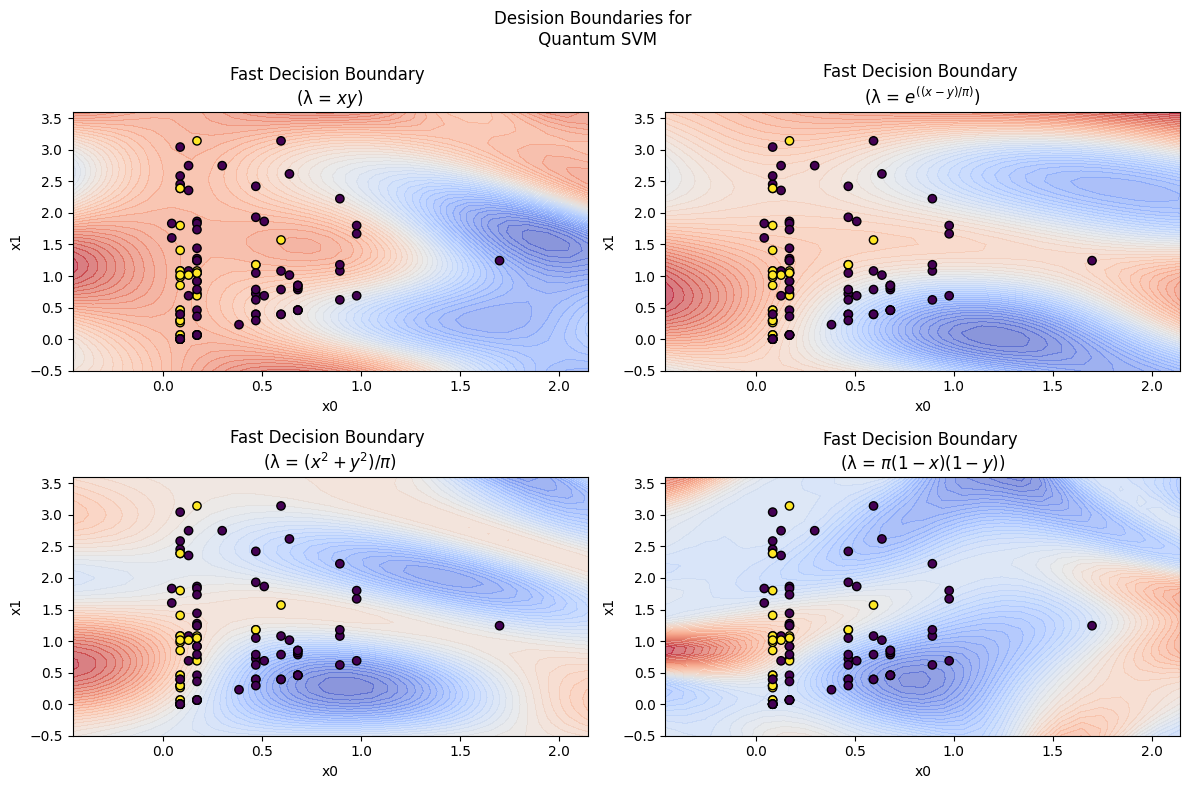

In [47]:
fig, ax = plt.subplots(2, 2)
fig.set_size_inches(12,8)
ax = ax.flatten()

for idx, phi in enumerate(phis):
    feature_qc = QuantumCircuit(2)
    parameters, feature_qc = utils.featureMap(feature_qc, phi)

    train_size = X_small.shape[0]
    test_size = norm_X_test.shape[0]

    train_kernel = np.full((train_size, train_size), np.nan)
    test_kernel = np.full((test_size, train_size), np.nan)

    train_kernel, test_kernel = utils.train_model(
        parameters=parameters,
        base_qc=feature_qc,
        train_kernel=train_kernel,
        test_kernel=test_kernel,
        X_train=X_small,
        X_test=norm_X_test,
        lam=0.5,
    )

    model = SVC(kernel="precomputed", C=0.5)
    model.fit(train_kernel, y_small)

    acc = model.score(test_kernel, y_test)
    print(f"λ = 0.5, accuracy = {acc:.3f}")

    plots.plot_decision_boundary_quantum(
        model=model,
        base_qc=feature_qc,
        parameters=parameters,
        norm_X_train=X_small,
        y_train=y_small,
        ax=ax[idx],
        title=sign_phis[idx],
        lam=0.5,
    )
fig.suptitle('Desision Boundaries for \n Quantum SVM')
fig.tight_layout()
plt.show()
fig.savefig('result/desisionBoundaries.jpg')


### Wtih Classical SVM and radial basis function kernel
- The RBF kernel on two samples $\mathbf{x}, \mathbf{x}' \in \mathbb{R}^n$ is defined as:

$$K(\mathbf{x}, \mathbf{x}') = \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\sigma^2}\right)$$

RBF accuracy: 0.7647058823529411
Linear accuracy: 0.7647058823529411
Polynomial accuracy: 0.7647058823529411


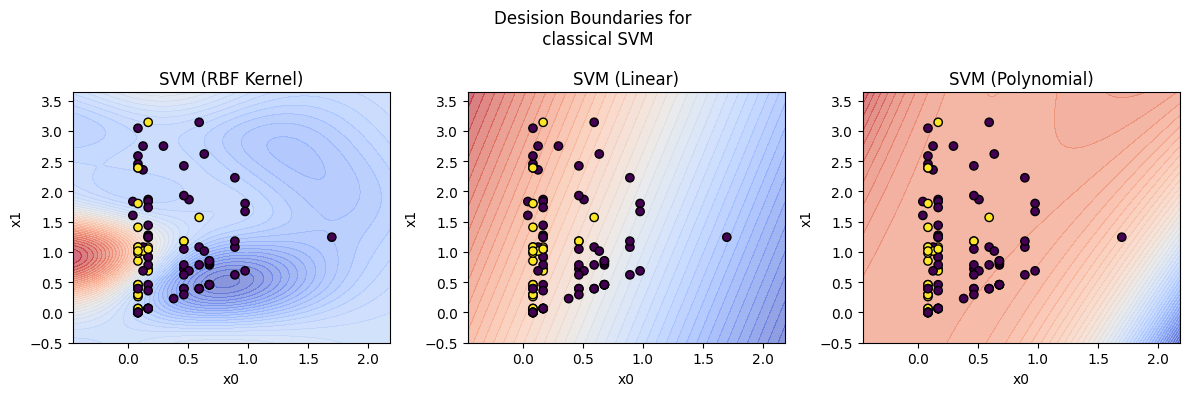

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Try RBF (most important baseline)
model_rbf = SVC(kernel='rbf', gamma='scale', C=1.0)
model_rbf.fit(X_small, y_small)
# RBF
plots.plot_decision_boundary_classical(
    model_rbf,
    X_small,
    y_small,
    ax[0],
    "SVM (RBF Kernel)"
)
acc_rbf = model_rbf.score(norm_X_test, y_test)
print("RBF accuracy:", acc_rbf)
# Linear
model_linear = SVC(kernel='linear', C=1.0)
model_linear.fit(X_small, y_small)

plots.plot_decision_boundary_classical(
    model_linear,
    X_small,
    y_small,
    ax[1],
    "SVM (Linear)"
)
acc_linear = model_linear.score(norm_X_test, y_test)
print("Linear accuracy:", acc_linear)

# Polynomial
model_poly = SVC(kernel='poly', degree=3, C=1.0)
model_poly.fit(X_small, y_small)

plots.plot_decision_boundary_classical(
    model_poly,
    X_small,
    y_small,
    ax[2],
    "SVM (Polynomial)"
)
acc_poly = model_poly.score(norm_X_test, y_test)
print("Polynomial accuracy:", acc_poly)
fig.suptitle('Desision Boundaries for \n classical SVM')
plt.tight_layout()

fig.savefig('result/Desision_Boundaries_classical.jpg')
plt.show()
